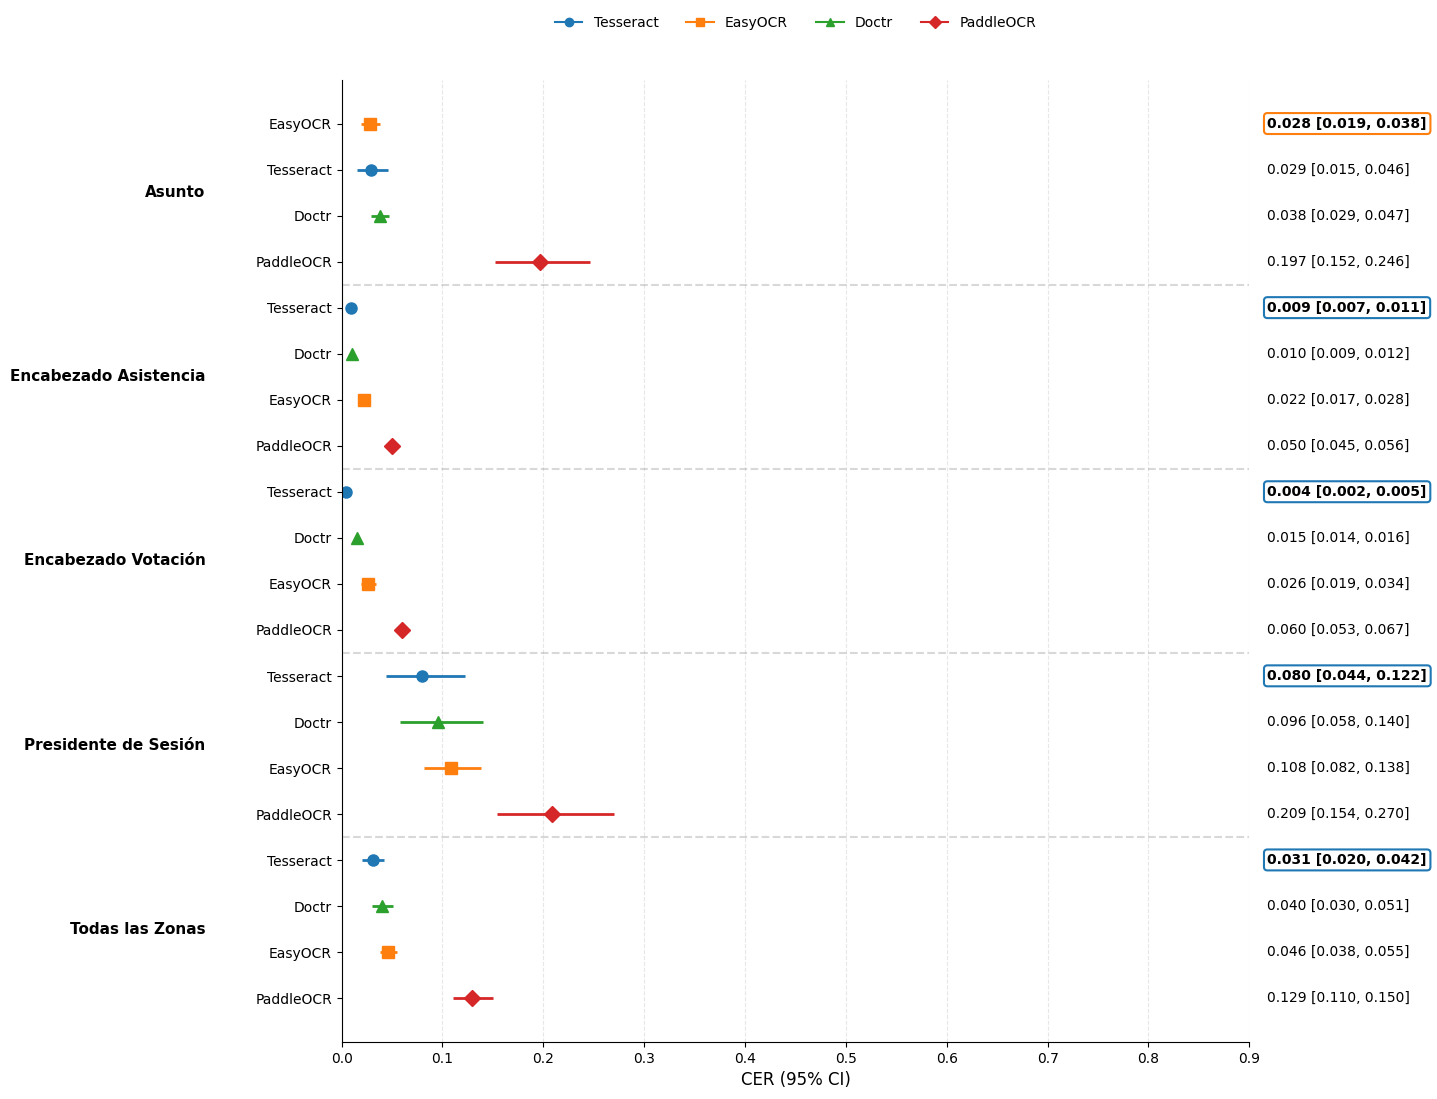

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# =========================
# DATOS
# =========================
rows = [
    ("Tesseract", "Asunto", 0.029, 0.015, 0.046),
    ("Tesseract", "Encabezado Asistencia", 0.009, 0.007, 0.011),
    ("Tesseract", "Encabezado Votación", 0.004, 0.002, 0.005),
    ("Tesseract", "Presidente de Sesión", 0.080, 0.044, 0.122),
    ("Tesseract", "Todas las Zonas", 0.031, 0.020, 0.042),

    ("EasyOCR", "Asunto", 0.028, 0.019, 0.038),
    ("EasyOCR", "Encabezado Asistencia", 0.022, 0.017, 0.028),
    ("EasyOCR", "Encabezado Votación", 0.026, 0.019, 0.034),
    ("EasyOCR", "Presidente de Sesión", 0.108, 0.082, 0.138),
    ("EasyOCR", "Todas las Zonas", 0.046, 0.038, 0.055),

    ("Doctr", "Asunto", 0.038, 0.029, 0.047),
    ("Doctr", "Encabezado Asistencia", 0.010, 0.009, 0.012),
    ("Doctr", "Encabezado Votación", 0.015, 0.014, 0.016),
    ("Doctr", "Presidente de Sesión", 0.096, 0.058, 0.140),
    ("Doctr", "Todas las Zonas", 0.040, 0.030, 0.051),

    ("PaddleOCR", "Asunto", 0.197, 0.152, 0.246),
    ("PaddleOCR", "Encabezado Asistencia", 0.050, 0.045, 0.056),
    ("PaddleOCR", "Encabezado Votación", 0.060, 0.053, 0.067),
    ("PaddleOCR", "Presidente de Sesión", 0.209, 0.154, 0.270),
    ("PaddleOCR", "Todas las Zonas", 0.129, 0.110, 0.150),
]

# =========================
# ESTILOS
# =========================
colors = {
    "Tesseract": "#1f77b4",
    "EasyOCR": "#ff7f0e",
    "Doctr": "#2ca02c",
    "PaddleOCR": "#d62728",
}

markers = {
    "Tesseract": "o",
    "EasyOCR": "s",
    "Doctr": "^",
    "PaddleOCR": "D",
}

# =========================
# AGRUPAR POR ZONA
# =========================
grouped = defaultdict(list)
for model, region, mean, low, high in rows:
    grouped[region].append((model, mean, low, high))

region_order = [
    "Asunto",
    "Encabezado Asistencia",
    "Encabezado Votación",
    "Presidente de Sesión",
    "Todas las Zonas",
]

# =========================
# CONSTRUIR DATA
# =========================
plot_data = []
y_labels = []
best_indices = []
separators = []
region_positions = {}

idx = 0

for region in region_order:
    group = sorted(grouped[region], key=lambda x: x[1])  # menor CER mejor
    best_model = group[0][0]

    region_positions[region] = []

    for model, mean, low, high in group:
        plot_data.append((model, region, mean, low, high))
        y_labels.append(model)
        region_positions[region].append(idx)

        if model == best_model:
            best_indices.append(idx)

        idx += 1

    separators.append(idx - 0.5)

# =========================
# PLOT
# =========================
y = np.arange(len(plot_data))[::-1]
fig, ax = plt.subplots(figsize=(14, 11))

for i, (model, region, mean, low, high) in enumerate(plot_data):
    yy = y[i]

    ax.errorbar(
        mean,
        yy,
        xerr=[[mean - low], [high - mean]],
        fmt=markers[model],
        color=colors[model],
        markersize=8,
        linewidth=2,
    )

    # texto derecha
    ax.text(
        1.02,
        yy,
        f"{mean:.3f} [{low:.3f}, {high:.3f}]",
        transform=ax.get_yaxis_transform(),
        va="center",
        fontsize=10,
        fontweight="bold" if i in best_indices else "normal",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor=colors[model],
            linewidth=1.5,
        ) if i in best_indices else None,
    )

# =========================
# HEADERS DE ZONA
# =========================
for region, indices in region_positions.items():
    y_pos = np.mean([y[i] for i in indices])

    ax.text(
        -0.15,
        y_pos,
        region,
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

# =========================
# SEPARADORES
# =========================
for sep in separators[:-1]:
    ax.axhline(y=sep, color="gray", linestyle="--", alpha=0.3)

# =========================
# CONFIG
# =========================
ax.set_yticks(y)
ax.set_yticklabels(y_labels, fontsize=10)

ax.set_xlabel("CER (95% CI)", fontsize=12)
ax.set_xlim(0.0, 0.90)

ax.grid(axis="x", linestyle="--", alpha=0.3)

# leyenda
for model in colors:
    ax.plot([], [], marker=markers[model], color=colors[model], label=model)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=4,
    frameon=False,
)

# limpieza
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.subplots_adjust(left=0.30, right=0.75)

plt.tight_layout()
plt.savefig("4_ocr_cer.png", dpi=300, bbox_inches="tight")
plt.show()